In [1]:
import warnings
warnings.filterwarnings('ignore')

from cluster_functions import *
import time
import random

from scipy.stats import linregress, ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
from sklearn.linear_model import LinearRegression
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
df.sort_index(inplace=True)
data.sort_index(inplace=True)

<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Ruan\AppData\Local\Temp\ipykernel_10176\428004029.py:25: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv('Dados\data.csv', index_col='Cluster')


In [2]:
for cluster in df.index:
    df.loc[cluster, 'bin_frac_corr'] = corr_fb(df, cluster,)
    df.loc[cluster, 'bin_frac_05_corr'] = corr_fb(df, cluster,q=0.5)

In [12]:
def calcula_sigma_sys(data, N, n_bootstrap=1000, random_state=None):
    
    rng = np.random.default_rng(random_state)

    clusters = data["Cluster"].unique()
    sigma_sys = []
    fb_corrigido = []
    for j, cluster in enumerate(clusters):
        df_cluster = data[data["Cluster"] == cluster].copy()
        idx_bin = df_cluster[df_cluster["flag_binary"] == 1].index 
        idx_single = df_cluster[df_cluster["flag_binary"] == 0].index
        bootstrap_fb = []
        for _ in range(n_bootstrap):
            aux = df_cluster.copy(deep=True)          

            if N[j] > 0:
                N_boots = rng.integers(0, N[j])
                if N_boots>len(idx_bin):
                    N_boots=len(idx_bin)
                idx = rng.choice(idx_bin, size=np.abs(N_boots), replace=False)
                aux.loc[idx, "flag_binary"] = 0
            else:
                N_boots = rng.integers(N[j], 0)
                if np.abs(N_boots)>len(idx_single):
                    N_boots=len(idx_single)
                idx = rng.choice(idx_single, size= np.abs(N_boots), replace=False)
                aux.loc[idx, "flag_binary"] = 1

            fb = aux["flag_binary"].sum() / len(aux)
            bootstrap_fb.append(fb)
        sigma_sys.append(np.std(bootstrap_fb))

    return  np.array(sigma_sys)

def calcula_sigma_bin(df, q):
    sigma_bin = []
    if q==0:
        #for cluster in df.index:
        #   fb = df.loc[cluster]['bin_frac']
        #    n_systems = df.loc[cluster]['n_systems']
        #    sigma_bin.append(np.sqrt(fb*(1-fb)/n_systems))
        sigma_bin = df['bin_frac_corr'].std()
    else:
        #for cluster in df.index:
        #    fb = df.loc[cluster]['bin_frac_05']
        #    n_systems = df.loc[cluster]['n_systems']
        #    sigma_bin.append(np.sqrt(fb*(1-fb)/n_systems))    
        sigma_bin = df['bin_frac_05_corr'].std()
    return np.array(sigma_bin)
        
def calcula_N(df, q=0):
    if q == 0:
        N = (df['bin_frac']-df['bin_frac_corr'])*df['n_systems']
    else:
        N = (df['bin_frac_05']-df['bin_frac_05_corr'])*df['n_systems']
        
    N = np.where((N>=0)&(N<=1),1,N)
    N = np.where((N<=0)&(N>=-1),-1,N)
    return np.array(N)
    
def calcula_er_fb(df, data, q, n_bootstrap=1000, random_state=1):
    
    N = calcula_N(df, q)    
    data['flag_binary'] = np.where(data["q"] > q, 1, 0) 
    
    sigma_sys = calcula_sigma_sys(data, N, n_bootstrap, random_state)
    sigma_bin = calcula_sigma_bin(df, q)
    sigma_fb = np.sqrt(sigma_bin**2 + sigma_sys**2)
    
    return sigma_fb

def calcula_N_systems(df, data):
    n_systems = []
    for cluster in df.index:
        n_systems.append(len(data[data['Cluster']==cluster]))
    return n_systems

data['Cluster']=data.index
data.index=range(0,len(data))
        
df['n_systems'] = calcula_N_systems(df, data)

df['e_bin_frac'] = calcula_er_fb(df, data, q=0, n_bootstrap=1000, random_state=1)

df['e_bin_frac_05'] = calcula_er_fb(df, data, q=0.5, n_bootstrap=1000, random_state=1)

#df.to_csv(r'Dados\results.csv', index=True)

IndexError: index 771 is out of bounds for axis 0 with size 771

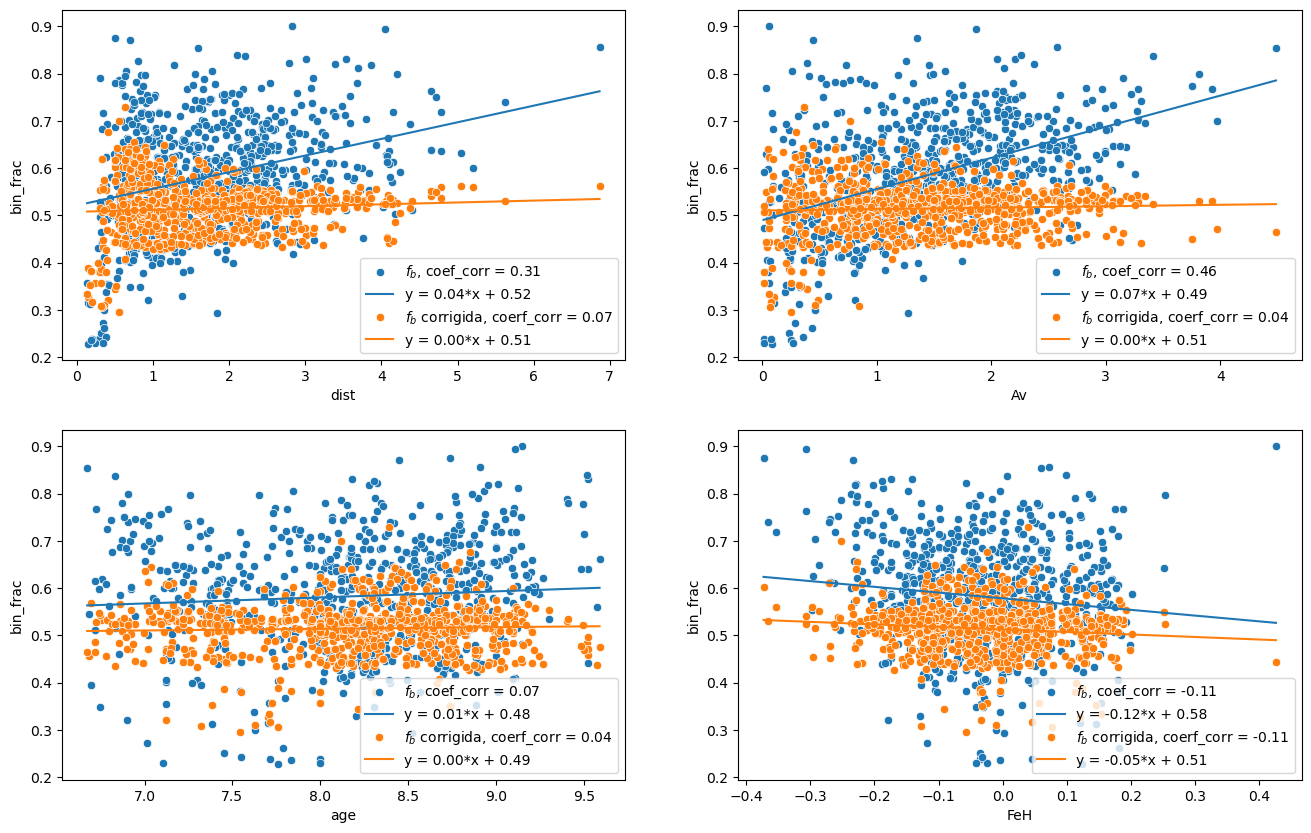

In [24]:
fig, axs = plt.subplots(2,2, figsize=(16,10))

y = 'bin_frac_corr'
xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    #Amostra total
    coef_corr = pearsonr(df[x],df['bin_frac'])
    sns.scatterplot(data=df, x =x, y='bin_frac', ax=axs[i,j],label=fr'$f_b$, coef_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df['bin_frac'])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    
    coef_corr = pearsonr(df[x],df['bin_frac_corr'])
    sns.scatterplot(x = df[x], y= df['bin_frac_corr'], ax=axs[i,j],label=f'$f_b$ corrigida, coerf_corr = {coef_corr[0]:.2f}')
    model = LinearRegression()
    model.fit(df[[x]], df['bin_frac_corr'])
    x_range = np.linspace(df[x].min(), df[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'y = {model.coef_[0]:.2f}*x + {model.intercept_:.2f}')
    

                
    
    
    j = j+1
    if j>1:
        j=0
        i = i+1

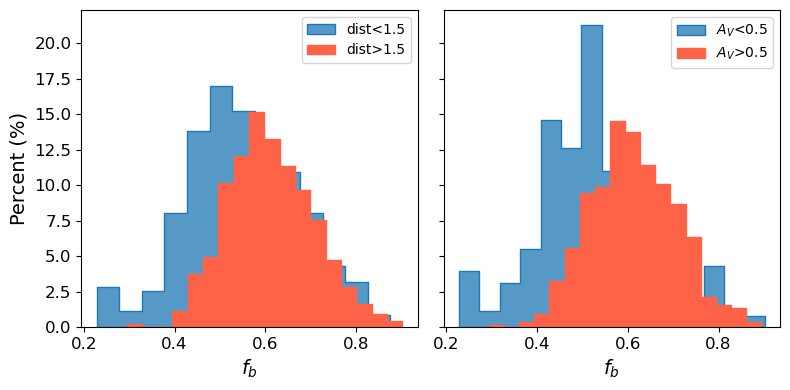

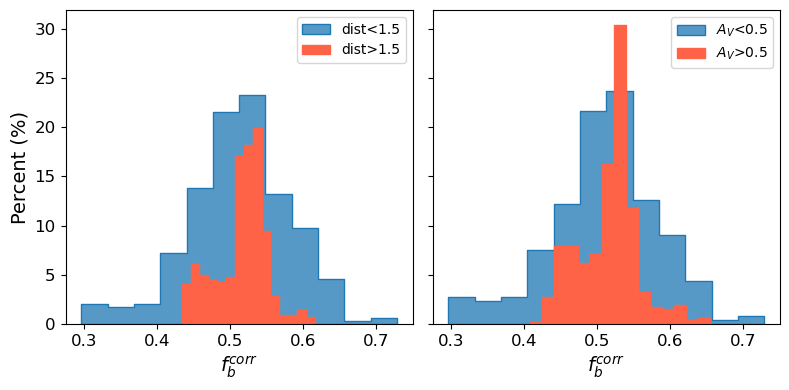

In [11]:
fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)

stat = 'percent'
sns.histplot(data=df[df['dist']<1.5], x='bin_frac', element='step', stat= stat, ax =axs[0], label = 'dist<1.5',)
sns.histplot(data=df[df['dist']>1.5], x='bin_frac', element='step', stat= stat, ax = axs[0], label = 'dist>1.5', color = 'tomato',
            alpha=1)

sns.histplot(data=df[df['Av']<1], x='bin_frac', element='step', stat= stat, ax = axs[1], label = r'$A_V$<0.5',)
sns.histplot(data=df[df['Av']>1], x='bin_frac', element='step', stat= stat, ax = axs[1], label = r'$A_V$>0.5', color = 'tomato',
            alpha=1)


for ax in axs.flat:
    ax.legend()
    ax.set_xlabel(r'$f_b$', fontdict=font)
    ax.set_ylabel('Percent (%)', fontdict=font)
    ax.tick_params(labelsize=12)
    


plt.tight_layout()
plt.savefig('Figures/systematic_bias.png',bbox_inches='tight', dpi=300)
plt.show()


fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)


sns.histplot(data=df[df['dist']<1.5], x='bin_frac_corr', element='step', stat= stat, ax =axs[0], label = 'dist<1.5', bins=12)
sns.histplot(data=df[df['dist']>1.5], x='bin_frac_corr', element='step', stat= stat, ax = axs[0], label = 'dist>1.5', color = 'tomato', bins=15,
            alpha=1)

sns.histplot(data=df[df['Av']<1], x='bin_frac_corr', element='step', stat= stat, ax = axs[1], label = r'$A_V$<0.5', bins=12)
sns.histplot(data=df[df['Av']>1], x='bin_frac_corr', element='step', stat= stat, ax = axs[1], label = r'$A_V$>0.5', color = 'tomato', bins=15,
            alpha=1)


for ax in axs.flat:
    ax.legend()
    ax.set_xlabel(r'$f_b^{corr}$', fontdict=font)
    ax.set_ylabel('Percent (%)', fontdict=font)
    ax.tick_params(labelsize=12)
    


plt.tight_layout()
plt.savefig('Figures/systematic_bias_corr.png',bbox_inches='tight', dpi=300)
plt.show()


In [49]:
#Compara as distribuições da razão de massa dos dois subconjuntos

low_av = df[df.Av <1.]['bin_frac_corr']
high_av = df[df.Av >1.]['bin_frac_corr']

# Kolmogorov–Smirnov test
ks_stat, ks_p = ks_2samp(low_av, high_av)
print(f"KS test: stat = {ks_stat:.4f}, p = {ks_p:.4f}")
if ks_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')
    
# Mann–Whitney U test    
u_stat, u_p = mannwhitneyu(low_av, high_av, alternative='two-sided')
print(f"Mann–Whitney U test: U = {u_stat:.4f}, p = {u_p:.4f}")

if u_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')

# Anderson–Darling test  
result = anderson_ksamp([low_av, high_av])
print(f"Anderson–Darling test: stat = {result.statistic:.4f}, p = {result.significance_level:.4f}")
if result.significance_level < 0.05: 
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')



KS test: stat = 0.1470, p = 0.0011
Distribuições distintas

Mann–Whitney U test: U = 62922.0000, p = 0.3465
Não há evidência de que são diferentes

Anderson–Darling test: stat = 14.0588, p = 0.0010
Distribuições distintas



In [46]:
df[df.dist<1.5]['bin_frac_corr'].describe()

count    348.000000
mean       0.513449
std        0.069349
min        0.296592
25%        0.472310
50%        0.516752
75%        0.553343
max        0.729122
Name: bin_frac_corr, dtype: float64

In [47]:
df[df.dist>1.5]['bin_frac_corr'].describe()

count    423.000000
mean       0.515538
std        0.035006
min        0.434210
25%        0.500868
50%        0.523518
75%        0.535331
max        0.616333
Name: bin_frac_corr, dtype: float64